# Lane Theory 01: Data & Features (v3)
Loads the raw elite 100m Freestyle dataset, applies the v3 scale-free,
performance-based feature engineering, validates the output, and runs
exploratory analysis. The elite dataset is a benchmark sample, not a
leaderboard — nothing here ranks swimmers against each other.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys

sys.path.insert(0, "../src")
from feature_engineering import engineer_features

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

## Load raw data

In [2]:
raw = pd.read_csv("../data/elite/raw/100m_freestyle_raw.csv")
print(f"Shape: {raw.shape}")
raw.head()

Shape: (40, 19)


,athlete_id,name,gender,height_cm,date_of_birth,final_time_sec,pb_50m_seconds,l1_reaction_time,l1_breakout_distance,l1_breakout_time,l1_stroke_count,l1_total_time,l2_breakout_distance,l2_breakout_time,l2_stroke_count,l2_total_time,l1_split_25m,l2_split_25m,race_date
0,1,Pan Zhanle,male,190,2004-08-04,46.40,21.92,0.62,13.2,4.0,30,22.28,8.0,3.0,34,24.12,9.9,11.3,2024-07-31
1,2,David Popovici,male,191,2004-09-15,46.51,21.82,0.64,14.0,4.4,29,22.49,8.0,3.0,35,24.02,9.8,11.1,2025-07-31
2,3,Egor Kornev,male,195,2004-02-06,46.74,21.06,0.61,14.0,4.3,27,22.06,9.0,3.7,31,24.68,9.4,11.2,2026-08-12
3,4,Jack Alexy,male,203,2003-01-19,46.81,21.32,0.68,13.4,4.1,26,22.45,8.0,3.0,32,24.36,9.7,11.3,2025-07-30
4,5,Kristof Milak,male,190,2000-02-20,46.87,21.46,0.67,15.0,5.0,28,22.41,11.0,4.4,33,24.46,9.6,11.2,2026-08-12


## Apply feature engineering

In [3]:
features = engineer_features(raw)
print(f"Shape: {features.shape}")
print(f"Columns added: {features.shape[1] - raw.shape[1]}")
features.head()

Shape: (40, 58)
Columns added: 39


,athlete_id,name,gender,height_cm,date_of_birth,final_time_sec,pb_50m_seconds,l1_reaction_time,l1_breakout_distance,l1_breakout_time,l1_stroke_count,l1_total_time,l2_breakout_distance,l2_breakout_time,l2_stroke_count,l2_total_time,l1_split_25m,l2_split_25m,race_date,age_at_race,l1_underwater_speed,l1_surface_distance,l1_surface_time,l1_surface_speed,l1_stroke_length,l1_relative_stroke_length,l1_stroke_rate,l1_stroke_index,l1_breakout_pct,l1_swolf,l2_underwater_speed,l2_surface_distance,l2_surface_time,l2_surface_speed,l2_stroke_length,l2_relative_stroke_length,l2_stroke_rate,l2_stroke_index,l2_breakout_pct,l2_swolf,l1_first25_speed,l1_second25_speed,intra_lap1_fade,intra_lap1_fade_ratio,l2_first25_speed,l2_second25_speed,intra_lap2_fade,intra_lap2_fade_ratio,finish_vs_fresh_ratio,pacing_decay_ratio,si_retention,breakout_decay_ratio,surface_speed_decay_ratio,front_end_pct,relative_stroke_length_drop,stroke_rate_change,swolf_change,breakout_drop
0,1,Pan Zhanle,male,190,2004-08-04,46.40,21.92,0.62,13.2,4.0,30,22.28,8.0,3.0,34,24.12,9.9,11.3,2024-07-31,19.989049,3.300000,36.8,18.28,2.013129,1.226667,0.645614,98.468271,2.469438,0.264,48.28,2.666667,42.0,21.12,1.988636,1.235294,0.650155,96.590909,2.456551,0.16,55.12,2.525253,2.019386,0.505866,0.799677,2.212389,1.950078,0.262311,0.881435,0.772231,1.082585,0.994781,0.606061,0.987833,1.016423,-0.004541,-1.877362,6.84,5.2
1,2,David Popovici,male,191,2004-09-15,46.51,21.82,0.64,14.0,4.4,29,22.49,8.0,3.0,35,24.02,9.8,11.1,2025-07-31,20.873374,3.181818,36.0,18.09,1.990050,1.241379,0.649937,96.185738,2.470407,0.280,47.09,2.666667,42.0,21.02,1.998097,1.200000,0.628272,99.904853,2.397716,0.16,56.02,2.551020,1.970055,0.580965,0.772262,2.252252,1.934985,0.317268,0.859133,0.758514,1.068030,0.970576,0.571429,1.004044,1.030706,0.021665,3.719115,8.93,6.0
2,3,Egor Kornev,male,195,2004-02-06,46.74,21.06,0.61,14.0,4.3,27,22.06,9.0,3.7,31,24.68,9.4,11.2,2026-08-12,22.513347,3.255814,36.0,17.76,2.027027,1.333333,0.683761,91.216216,2.702703,0.280,44.76,2.432432,41.0,20.98,1.954242,1.322581,0.678246,88.655863,2.584643,0.18,51.98,2.659574,1.974724,0.684851,0.742496,2.232143,1.854599,0.377543,0.830861,0.697329,1.118767,0.956318,0.642857,0.964093,1.047483,0.005514,-2.560353,7.22,5.0
3,4,Jack Alexy,male,203,2003-01-19,46.81,21.32,0.68,13.4,4.1,26,22.45,8.0,3.0,32,24.36,9.7,11.3,2025-07-30,22.527036,3.268293,36.6,18.35,1.994550,1.407692,0.693444,85.013624,2.807713,0.268,44.35,2.666667,42.0,21.36,1.966292,1.312500,0.646552,89.887640,2.580758,0.16,53.36,2.577320,1.960784,0.616535,0.760784,2.212389,1.914242,0.298147,0.865237,0.742726,1.085078,0.919167,0.597015,0.985832,1.053002,0.046893,4.874016,9.01,5.4
4,5,Kristof Milak,male,190,2000-02-20,46.87,21.46,0.67,15.0,5.0,28,22.41,11.0,4.4,33,24.46,9.6,11.2,2026-08-12,26.475017,3.000000,35.0,17.41,2.010339,1.250000,0.657895,96.496267,2.512924,0.300,45.41,2.500000,39.0,20.06,1.944167,1.181818,0.622010,98.703888,2.297652,0.22,53.06,2.604167,1.951600,0.652566,0.749415,2.232143,1.885370,0.346773,0.844646,0.723982,1.091477,0.914334,0.733333,0.967084,1.044268,0.035885,2.207622,7.65,4.0


## Validation

Sanity-check the engineered values before trusting this dataset, arithmetic consistency, then physical plausibility of all v3 metrics,
including the two new self-referential decay ratios.

In [4]:
implied_total = features["l1_total_time"] + features["l2_total_time"]
diff = (features["final_time_sec"] - implied_total).abs()

print(f"Max discrepancy: {diff.max():.4f} sec")
print(f"Rows with discrepancy > 0.01s: {(diff > 0.01).sum()}")

Max discrepancy: 0.0000 sec
Rows with discrepancy > 0.01s: 0


In [5]:
sanity_cols = [
    "l1_surface_speed", "l2_surface_speed",
    "l1_stroke_rate", "l2_stroke_rate",
    "l1_stroke_length", "l2_stroke_length",
    "l1_relative_stroke_length", "l2_relative_stroke_length",
    "l1_stroke_index", "l2_stroke_index",
    "pacing_decay_ratio", "si_retention",
    "breakout_decay_ratio", "surface_speed_decay_ratio",
    "l1_breakout_pct", "l2_breakout_pct",
    "age_at_race", "front_end_pct",
]
features[sanity_cols].describe().loc[["min", "max", "mean"]]

,l1_surface_speed,l2_surface_speed,l1_stroke_rate,l2_stroke_rate,l1_stroke_length,l2_stroke_length,l1_relative_stroke_length,l2_relative_stroke_length,l1_stroke_index,l2_stroke_index,pacing_decay_ratio,si_retention,breakout_decay_ratio,surface_speed_decay_ratio,l1_breakout_pct,l2_breakout_pct,age_at_race,front_end_pct
min,1.733143,1.703883,85.013624,87.378641,1.019444,0.987805,0.570988,0.542092,1.789269,1.724401,1.031994,0.813247,0.511278,0.894944,0.17600,0.1000,19.304586,1.007965
max,2.119099,1.998097,109.775222,109.615385,1.407692,1.322581,0.698080,0.678246,2.807713,2.584643,1.134146,1.063954,0.993333,1.023197,0.30000,0.2980,28.309377,1.072903
mean,1.900215,1.857689,96.775332,99.050996,1.181706,1.128401,0.636720,0.608234,2.253026,2.101301,1.083159,0.936540,0.642463,0.978607,0.26165,0.1688,23.215058,1.046013


In [6]:
spot_check_cols = [
    "name",
    "pacing_decay_ratio", "si_retention",
    "breakout_decay_ratio", "surface_speed_decay_ratio",
    "l1_relative_stroke_length", "l2_relative_stroke_length",
]
features[spot_check_cols].head(5)

,name,pacing_decay_ratio,si_retention,breakout_decay_ratio,surface_speed_decay_ratio,l1_relative_stroke_length,l2_relative_stroke_length
0,Pan Zhanle,1.082585,0.994781,0.606061,0.987833,0.645614,0.650155
1,David Popovici,1.068030,0.970576,0.571429,1.004044,0.649937,0.628272
2,Egor Kornev,1.118767,0.956318,0.642857,0.964093,0.683761,0.678246
3,Jack Alexy,1.085078,0.919167,0.597015,0.985832,0.693444,0.646552
4,Kristof Milak,1.091477,0.914334,0.733333,0.967084,0.657895,0.622010


**Observations:**

Consistency check (Cell 8) passed cleanly (max discrepancy 0.0000s across
all 40 rows).

All four new decay ratios fall in sensible elite ranges:
- `pacing_decay_ratio`: 1.032–1.134 (mean 1.083) — elite Lap 2 runs
  roughly 3–13% slower than Lap 1
- `si_retention`: 0.813–1.064 (mean 0.937) — most elites retain ~90-95%
  of Lap 1 stroke efficiency into Lap 2; the max above 1.0 means at
  least one swimmer's efficiency actually improved in Lap 2, worth a
  closer look later
- `breakout_decay_ratio`: 0.511–0.993 (mean 0.642) — wide spread, meaning
  underwater endurance off the second wall varies substantially even
  among elites; this range closely matches the "optimal benchmark" figure
  referenced in the sample coach's report reviewed earlier (~0.64)
- `surface_speed_decay_ratio`: 0.895–1.023 (mean 0.979) — confirms elites'
  clean-swimming speed barely drops between laps; most of their race-time
  loss likely comes from elsewhere (turn/underwater), not surface fatigue

Stroke Index (`l1_stroke_index`/`l2_stroke_index`) and relative stroke
length ranges are consistent with earlier validation. `age_at_race`
(19.3–28.3) and `front_end_pct` (1.008–1.073) are unchanged from before
and remain sane.

This confirms the v3 feature set is working correctly and ready for EDA.

## Save processed dataset

In [7]:
features.to_csv("../data/elite/processed/100m_freestyle_features.csv", index=False)
print("Saved!")

Saved!


## Exploratory Data Analysis

Kept short; groundwork, not the point of the project. Framed throughout
as "what's associated with fast swimming," never "who's fastest" — the
elite dataset is a benchmark sample, not a leaderboard.

### Distribution of the four decay ratios, by gender

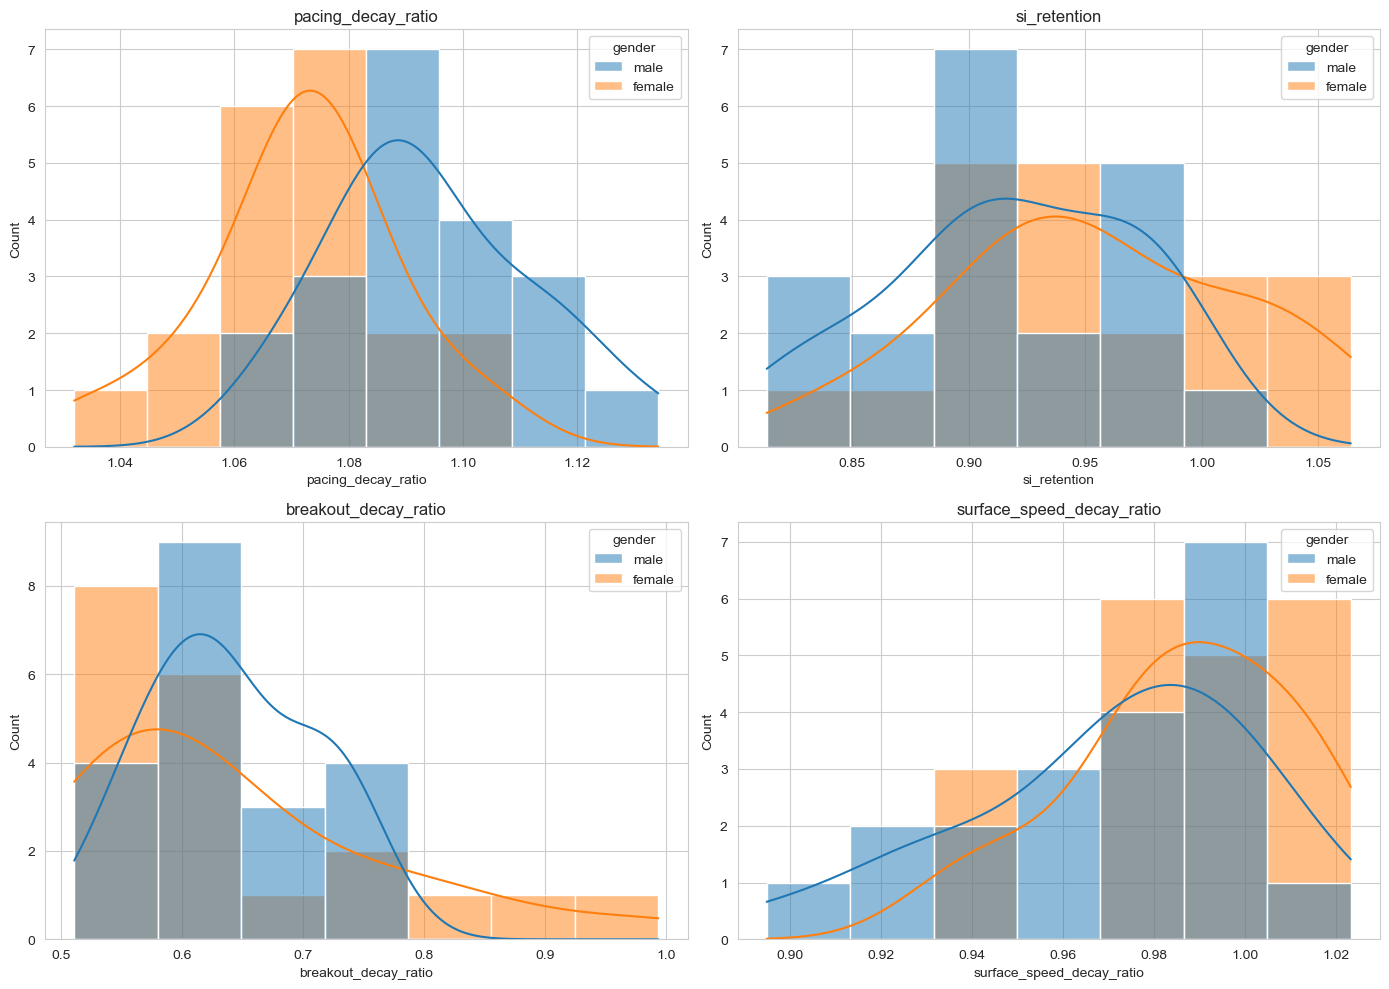

gender                              female       male
pacing_decay_ratio        count  20.000000  20.000000
                          mean    1.071744   1.094573
                          std     0.016900   0.017905
                          min     1.031994   1.065818
                          25%     1.066308   1.084455
                          50%     1.072752   1.091012
                          75%     1.079726   1.106942
                          max     1.105326   1.134146
si_retention              count  20.000000  20.000000
                          mean    0.954829   0.918251
                          std     0.062749   0.053590
                          min     0.833228   0.813247
                          25%     0.917955   0.889521
                          50%     0.950760   0.916751
                          75%     1.013216   0.970165
                          max     1.063954   0.994781
breakout_decay_ratio      count  20.000000  20.000000
                          mean    0.643580   0.641346
                          std     0.128812   0.067456
                          min     0.511278   0.527778
                          25%     0.547710   0.593284
                          50%     0.615087   0.636054
                          75%     0.697339   0.695813
                          max     0.993333   0.758621
surface_speed_decay_ratio count  20.000000  20.000000
                          mean    0.986534   0.970681
                          std     0.024836   0.032068
                          min     0.933241   0.894944
                          25%     0.974876   0.958626
                          50%     0.988693   0.974905
                          75%     1.005763   0.991223
                          max     1.023197   1.021452

In [8]:
decay_cols = ["pacing_decay_ratio", "si_retention", "breakout_decay_ratio", "surface_speed_decay_ratio"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, decay_cols):
    sns.histplot(data=features, x=col, hue="gender", kde=True, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

features.groupby("gender")[decay_cols].describe().T

**Observations:**

Female elites show consistently *less* proportional decay than male
elites across three of the four ratios: `pacing_decay_ratio` (female
mean 1.072 vs. male 1.095), `si_retention` (female 0.955 vs. male 0.918
— higher is better, meaning female swimmers retain more Lap 1 efficiency),
and `surface_speed_decay_ratio` (female 0.987 vs. male 0.971). Only
`breakout_decay_ratio` is essentially identical between genders (0.644 vs.
0.641). This is a genuinely interesting finding worth a note in the
README: male elite sprinters appear to fade proportionally more overall
(pacing, stroke efficiency, surface speed) than female elite sprinters at
this distance, with underwater turn mechanics being the one dimension
where both genders behave similarly.

### Relationship between each decay ratio and final_time_sec

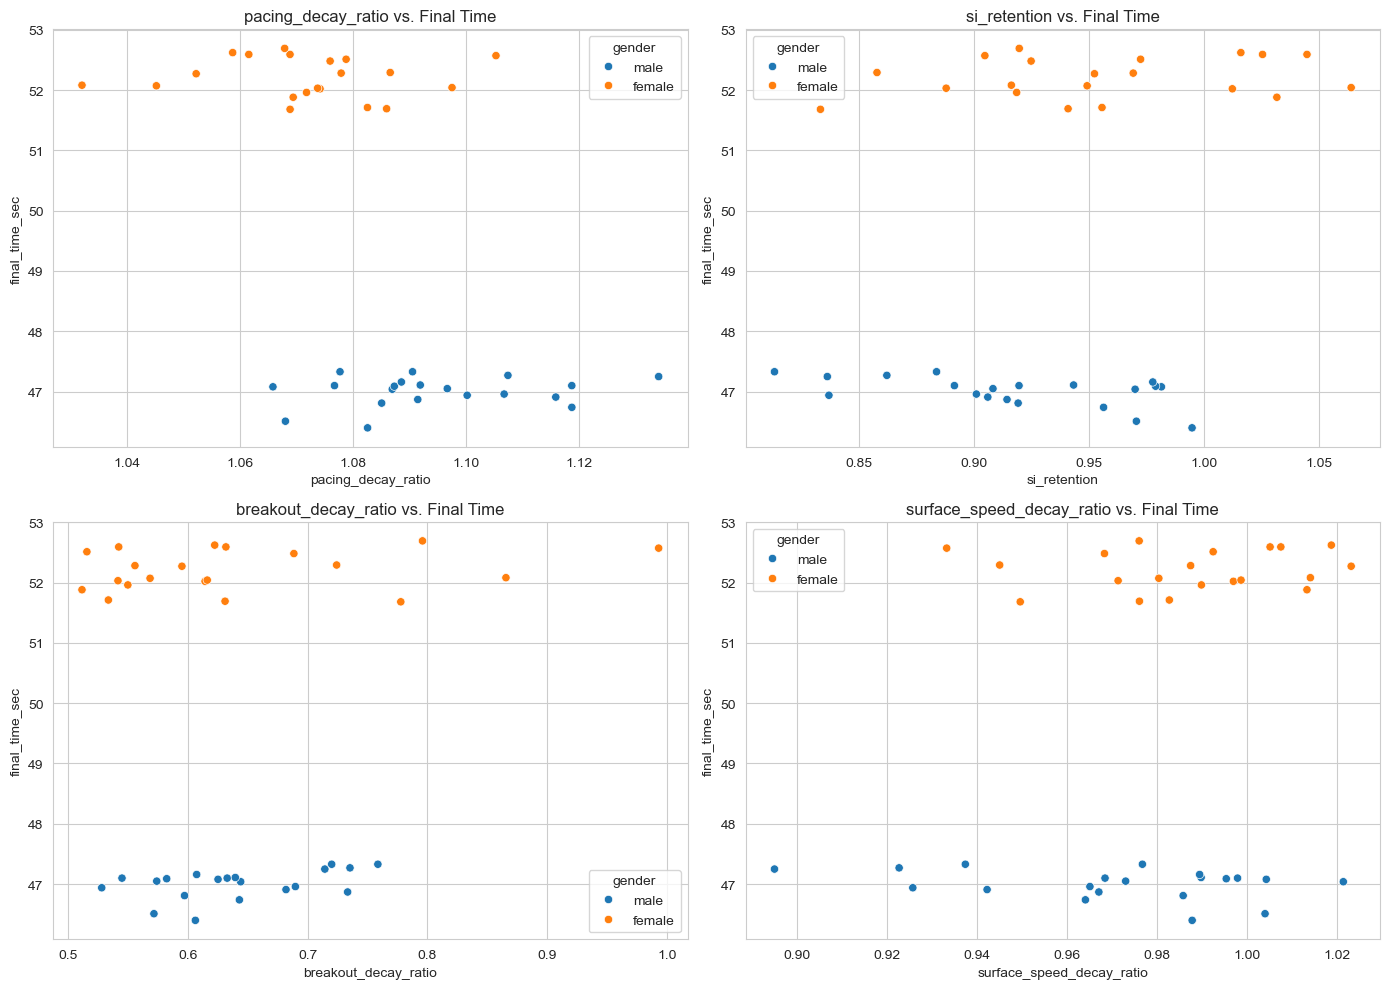

pacing_decay_ratio          -0.548793
si_retention                 0.296387
breakout_decay_ratio         0.041706
surface_speed_decay_ratio    0.259656
final_time_sec               1.000000
Name: final_time_sec, dtype: float64

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, decay_cols):
    sns.scatterplot(data=features, x=col, y="final_time_sec", hue="gender", ax=ax)
    ax.set_title(f"{col} vs. Final Time")

plt.tight_layout()
plt.show()

features[decay_cols + ["final_time_sec"]].corr()["final_time_sec"]

**Observations — important confound to flag:**

Correlations (computed across the full 40-swimmer mixed-gender set):
`pacing_decay_ratio` (-0.549), `si_retention` (+0.296),
`surface_speed_decay_ratio` (+0.260), `breakout_decay_ratio` (+0.042,
essentially none).

At face value, the negative pacing_decay correlation looks
counterintuitive — it suggests *more* proportional slowdown is associated
with a *faster* final time. But this is very likely a **confound from
mixing genders in one correlation**: male elites are both faster overall
(~47s vs. ~52s) AND have a higher mean pacing_decay_ratio (per Cell 17),
so pooling both genders together makes the ratio look like a predictor of
speed when it's actually just tracking which gender group a swimmer
belongs to (a classic Simpson's paradox pattern). The same logic likely
explains the si_retention and surface_speed_decay correlations.

**This is a strong practical justification for Phase 4's per-gender
modeling design** — a correlation or model fit across the pooled dataset
would be misleading here, exactly the kind of confound gender-separated
models are meant to avoid. A true within-gender relationship between
these ratios and final time would need to be checked per gender
separately, which Phase 4's benchmark models will do properly.

### Raw vs. relative stroke length — confirming the normalization matters

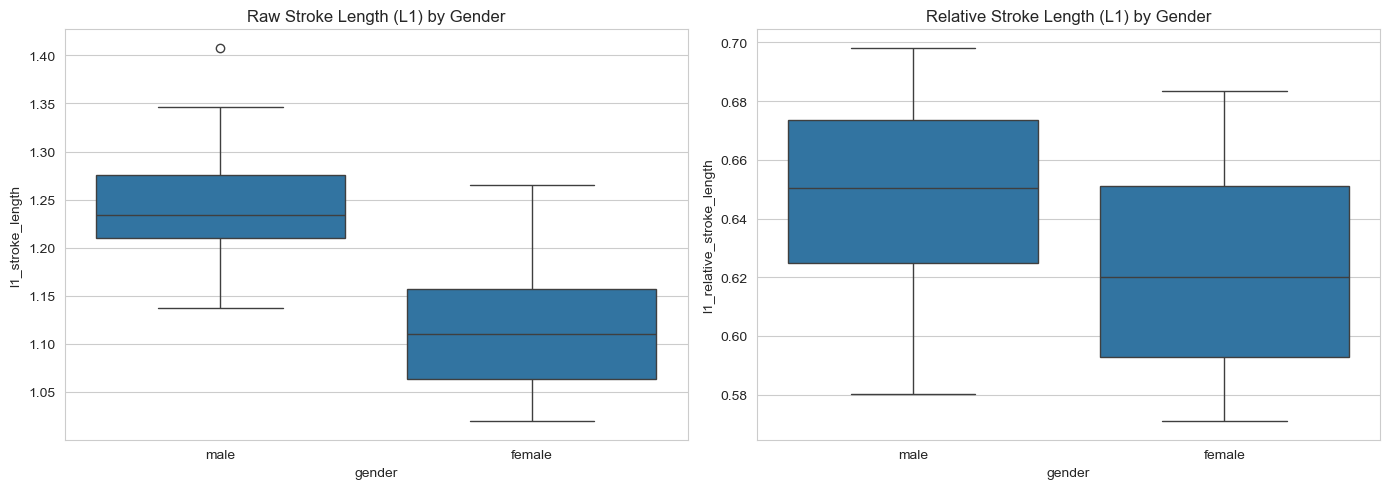

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=features, x="gender", y="l1_stroke_length", ax=axes[0])
axes[0].set_title("Raw Stroke Length (L1) by Gender")

sns.boxplot(data=features, x="gender", y="l1_relative_stroke_length", ax=axes[1])
axes[1].set_title("Relative Stroke Length (L1) by Gender")

plt.tight_layout()
plt.show()

**Observations:**

Raw stroke length shows almost no overlap between genders (male IQR
1.21–1.28m, female IQR 1.06–1.16m — clearly separated boxes). Relative
stroke length shows substantially more overlap (male IQR 0.625–0.673,
female IQR 0.593–0.650, with full whisker ranges overlapping almost
entirely: male 0.580–0.698, female 0.570–0.685). This confirms the
height-normalization is doing genuine work, not just being mathematically
present: once adjusted for body size, male and female elite stroke
efficiency looks far more similar than raw numbers suggest — consistent
with the earlier finding that the two groups are executing structurally
similar, well-optimized strokes, just scaled to different frames.

## Data Dictionary

### Identity & context
| Column | Description |
|---|---|
| `athlete_id` | Unique identifier per swimmer |
| `name`, `gender`, `height_cm`, `date_of_birth` | Athlete profile. `height_cm` is retained for context/display only — it is NOT used as a model input or grouping key, only as an input to `relative_stroke_length`'s normalization math |
| `race_date` | Date of the specific swim recorded |
| `age_at_race` | Age at time of race (computed from DOB + race_date) |
| `final_time_sec` | Official race time, in seconds |
| `pb_50m_seconds` | Athlete's flat-start 50m personal best — used as a speed ceiling reference |

### Raw per-lap inputs (l1 = first 50m, l2 = second 50m)
| Column | Description |
|---|---|
| `l{n}_reaction_time` | Time off the blocks (Lap 1 only) |
| `l{n}_breakout_distance` | Distance underwater before surfacing, in meters |
| `l{n}_breakout_time` | Time underwater before surfacing, in seconds |
| `l{n}_stroke_count` | Number of strokes on the surface portion of the lap |
| `l{n}_total_time` | Total time for that lap (wall-to-wall) |
| `l1_split_25m` | Cumulative time from race start to the 25m mark |
| `l2_split_25m` | Time from the Lap 2 wall push-off to the 75m mark (lap-relative) |

### Engineered per-lap features
| Column | Description |
|---|---|
| `l{n}_underwater_speed` | breakout_distance ÷ breakout_time (m/s) |
| `l{n}_surface_distance` | 50m − breakout_distance |
| `l{n}_surface_time` | lap_total_time − breakout_time |
| `l{n}_surface_speed` | surface_distance ÷ surface_time (m/s) — "clean swimming" velocity, excluding underwater phase |
| `l{n}_stroke_length` (DPS) | surface_distance ÷ stroke_count (m/stroke) — raw distance per stroke |
| `l{n}_relative_stroke_length` | stroke_length ÷ height (meters) — height-normalized, so stroke efficiency is comparable across body sizes |
| `l{n}_stroke_rate` | (stroke_count ÷ surface_time) × 60 (cycles/min) |
| `l{n}_stroke_index` (SI) | surface_speed × stroke_length — standard swim-science efficiency metric, multiplicative (unlike SWOLF, which adds differently-scaled units) |
| `l{n}_breakout_pct` | breakout_distance ÷ 50 — proportion of the lap covered underwater |
| `l{n}_swolf` | surface_time + stroke_count — lower is more efficient |

### Engineered quarter-split (25m) features
| Column | Description |
|---|---|
| `l{n}_first25_speed`, `l{n}_second25_speed` | Speed in the first vs. second 25m of that lap |
| `intra_lap1_fade`, `intra_lap2_fade` | first25_speed − second25_speed — how much a swimmer slows *within* a single lap |
| `finish_vs_fresh_ratio` | l2_second25_speed ÷ l1_first25_speed — most fatigued segment's speed vs. the freshest segment's speed |

### Engineered race-level features
| Column | Description |
|---|---|
| `pacing_decay_ratio` | l2_total_time ÷ l1_total_time — self-referential, scale-free. >1 means Lap 2 was slower |
| `si_retention` | l2_stroke_index ÷ l1_stroke_index — self-referential. Closer to 1.0 means better efficiency retention into Lap 2 |
| `breakout_decay_ratio` | l2_breakout_distance ÷ l1_breakout_distance — self-referential. How much underwater distance is retained on the second wall push-off |
| `surface_speed_decay_ratio` | l2_surface_speed ÷ l1_surface_speed — self-referential. Isolates clean-swimming fade from turn/underwater fade |
| `front_end_pct` | l1_total_time ÷ pb_50m_seconds — how conservatively/aggressively the swimmer opened, relative to their own speed ceiling |
| `relative_stroke_length_drop` | l1_relative_stroke_length − l2_relative_stroke_length |
| `stroke_rate_change` | l2_stroke_rate − l1_stroke_rate |
| `swolf_change` | l2_swolf − l1_swolf |
| `breakout_drop` | l1_breakout_distance − l2_breakout_distance (raw difference; `breakout_decay_ratio` above is the preferred, scale-free version — this is kept for reference/interpretability only) |

**Reminder:** this dataset is a benchmark sample of well-executed 100m
Freestyle races — it is never used to rank swimmers against each other.
Its purpose is to define ranges of technique/pacing patterns associated
with fast swimming, for comparison against any individual's own race.